<p style="font-family:Nazanin; font-size:140%; text-align:center;" dir="rtl">
   «تحلیل داده‌ آگهی‌های دیوار»
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری کتابخانه های مورد نیاز
</p>

In [51]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری داده های مورد نیاز
</p>

In [52]:
data = pd.read_csv('Daghighe_project/divar_real_estate_ads.csv', encoding="utf-8",engine = 'python')
#data = pd.read_csv('Daghighe_project/sampled_data.csv',encoding = 'utf-8', engine='python')

<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش اول : بررسی کیفیت داده
</p>
<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید .
</p>

In [53]:
df_na = data.isna().sum().reset_index()
df_na.columns = ["column", "missing_nums"]
df_na["percent_missing"] = (df_na["missing_nums"] / len(data)) * 100
# sort columns from lowest number of NA's to the highest
df_na = df_na.sort_values(by="percent_missing", ascending=True)
print("columns with lowest number of NA's")
print(df_na.head(10))
print("\n")
print("columns with highest number of NA's")
print((df_na.tail(10)))

columns with lowest number of NA's
               column  missing_nums  percent_missing
0           cat2_slug             0           0.0000
4    created_at_month             0           0.0000
6         description             0           0.0000
1           cat3_slug             1           0.0001
2           city_slug             2           0.0002
7               title            54           0.0054
23      building_size         19606           1.9606
27        rooms_count        154101          15.4101
34  construction_year        184172          18.4172
33        has_parking        271844          27.1844


columns with highest number of NA's
                        column  missing_nums  percent_missing
46                    has_pool        970610          97.0610
47                 has_jacuzzi        971272          97.1272
48                   has_sauna        971521          97.1521
50               property_type        972943          97.2943
52       extra_person_capacity    

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. آیا ردیف‌های تکراری در داده وجود دارد؟
</p>

In [54]:
print('number of duplicated rows: ',data.duplicated(keep = 'last').sum())


number of duplicated rows:  0


<p style="font-family:Nazanin; font-size:120%; text-align:right;" dir="rtl">
   برای ادامه پروژه نیاز داریم که یک پیش پردازش بر روی دیتافریم صورت پذیرد . 
</p>

In [63]:
#extract meter from descritpion
def extract_meter_numbers(description):
    if pd.isna(description):
        return np.nan
    matches = re.findall(r'(\d+)\s*متر\s*', description)
    if matches:
        return float(matches[0])
    return np.nan


#cleaning data frame function
def cleaning_data(data: pd.DataFrame) -> pd.DataFrame:

###->    # 1. Remove columns that more than 90% of its data is NA
    data = data.dropna(axis=1, thresh=int(0.1 * len(data)))

###->     #2. complete building size with 1 m^2 with number exctracter from description
    data['description'].astype(str)
    data['meter_numbers'] = data['description'].apply(extract_meter_numbers)
    counter = 0
    for row in data.itertuples():
        if row.building_size == 1:
            data['building_size'][counter] = row.meter_numbers
        counter += 1
    data = data.drop(columns=['meter_numbers'])

    data['description'] = data['description'].astype(str)
    data['meter_numbers'] = data['description'].apply(extract_meter_numbers)
    for row in data.itertuples():
        if row.building_size == 1:
            data.loc[row.Index, 'building_size'] = row.meter_numbers
    
    data = data.drop(columns=['meter_numbers'])


###->     #3. remove outliers from price and rent value by using price/M^2 and rent/M^2

    #calculate price per square meter and rent per square meter
    data['price_per_meter'] = (data['price_value'] / data['building_size'])/1000000

    #since we have credit and rent price we need total rent
    data['total_rent'] = data['rent_value']*30 + data['credit_value']
    data['rent_price_per_meter'] = (data['total_rent'] / data['building_size'])/1000000

    # Calculate Q1, Q3, and IQR for 'price_value'
    Q1_p = data['price_per_meter'].quantile(0.25)
    Q3_p = data['price_per_meter'].quantile(0.75)
    IQR_p = Q3_p - Q1_p

    # Define the lower and upper bounds for outliers in price values
    lower_bound_p = Q1_p - 1.5 * IQR_p
    upper_bound_p = Q3_p + 1.5 * IQR_p

    # Calculate Q1, Q3, and IQR for 'rent_value'
    Q1_r = data['rent_price_per_meter'].quantile(0.25)
    Q3_r = data['rent_price_per_meter'].quantile(0.75)
    IQR_r = Q3_r - Q1_r

    # Define the lower and upper bounds for outliers in rent values
    lower_bound_r = Q1_r - 1.5 * IQR_r
    upper_bound_r = Q3_r + 1.5 * IQR_r

    data = data[(data['price_per_meter'] > lower_bound_p) & (data['price_per_meter'] < upper_bound_p) |
                  (data['rent_price_per_meter'] > lower_bound_r) & (data['rent_price_per_meter'] < upper_bound_r)
                   ]
  

###->     #4. Make some columns' data standard

    ### rooms_count
    data['rooms_count'] = data['rooms_count'].replace({
   'یک' : 1,
    'دو' : 2,
    'سه' : 3,
    'چهار': 4,
    'بدون اتاق' : 0,
    'پنج یا بیشتر' : 5    })

    data['rooms_count'] = data['rooms_count'].astype('Int32')
    
    
    ### construction_year
    
    persian_to_english = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

    data['construction_year'] = (
    data['construction_year']
    .astype(str)
    .replace('قبل از ۱۳۷۰', '1369')  
    .apply(lambda x: x.translate(persian_to_english))
    )

    data['construction_year'] = pd.to_numeric(data['construction_year'], errors = 'coerce').astype('Int64')

        
    
###->     #6. remove duplicated rows in data frame

    data = data.drop_duplicates(keep = 'last').reset_index(drop = True)

        
###->     #7.General Cleaning for numerical and object types of data
    bool_cols = [c for c in data.columns if data[c].dtype == 'object' and
             set(data[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]    
    for col in bool_cols:
        data[col] = data[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})
    
    numeric_cols = [col for col in data.columns if (data[col].dtype != 'object') and (data[col].dtype != 'category')]
    categorical_cols = [col for col in data.columns if (data[col].dtype == 'object')
                        and (data[col].dtype == 'category')
                        and col not in bool_cols]
    
        
    for col in set(numeric_cols + bool_cols):
        data[col] = data[col].fillna(0)
        
    for col in categorical_cols:
        data[col] = data[col].filna('unknown').astype(str)
        
###->     #5. Add a Column called size_per_room
    
    data['size_per_room'] = data['building_size'] / (data['rooms_count'] + 1)
    
    
###->     #8.Combine Price Mode and Rent Mode - Combine Price value and Rent value

    data['mode_rent_or_price'] = data['rent_mode'].combine_first(data['price_mode'])    
    data['value_rent_or_price'] = data['rent_price_per_meter'].combine_first(data['price_per_meter'])
    
###->     #9. Remove missing values in target column

    data = data.dropna(subset=['value_rent_or_price'])
###-> #10 . Remove created at month column as it is useless in entire analysis
    
    data.drop(columns=['created_at_month'], inplace=True)
        
       
    return data




def detect_column_types(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
   
    text_cols = [c for c in categorical_cols if df[c].nunique() > 50]
    
    categorical_cols = [c for c in categorical_cols if c not in text_cols]
    
    return numeric_cols, categorical_cols, text_cols


df = cleaning_data(data)
print('\n📌shape of data frame after cleaning :',df.shape)
print('\n')


📌shape of data frame after cleaning : (836934, 46)




<p style="font-family:Nazanin; font-size:150%; text-align:right;color:blue;" dir="rtl">
    بخش دوم : تحلیل اکتشافی داده (EDA)
</p>

<p style="font-family:Nazanin; font-size:110%; text-align:right;" dir="rtl">
    1. توزیع و مشخصه‌های آماری هر یک از ستون‌ها (متغیرهای عددی) را ترسیم و بررسی کنید.
</p>

In [64]:
#extract different types of columns 
numerical,categorical,text = detect_column_types(df)

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 مشخصه های آماری ستون های عددی در زیر آمده است. این مشخصه ها شامل توصیف آماری تعداد،میانگین،انحراف معیار،کمترین، بیشترین و چهارک ها می باشد. علاوه بر آن چولگی و کشیده گی نیز آورده شده است 
</p>

In [65]:
numeric_df = df[numerical]

# --- Statistical characteristics ---
print("📌 Descriptive Statistics:")
print(numeric_df.describe())

print("\n📌 Skewness:")
print(numeric_df.apply(lambda x: skew(x.dropna())))

print("\n📌 Kurtosis:")
print(numeric_df.apply(lambda x: kurtosis(x.dropna())))



📌 Descriptive Statistics:
         rent_value   price_value  credit_value  transformable_credit  \
count  8.369340e+05  8.369340e+05  8.369340e+05          8.369340e+05   
mean   7.233058e+06  3.125212e+09  1.777119e+08          1.777089e+08   
std    2.059012e+09  1.618595e+11  1.651428e+10          1.651428e+10   
min    0.000000e+00  0.000000e+00  0.000000e+00          0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00          0.000000e+00   
50%    0.000000e+00  1.050000e+09  0.000000e+00          0.000000e+00   
75%    2.000000e+06  3.150000e+09  1.500000e+08          1.500000e+08   
max    1.400000e+12  1.000000e+14  1.111111e+13          1.111111e+13   

       transformable_rent     land_size  building_size  rooms_count  \
count        8.369340e+05  8.369340e+05   8.369340e+05     836934.0   
mean         7.232812e+06  8.544052e+02   3.064788e+03     1.638013   
std          2.059012e+09  5.535216e+04   1.125526e+05     1.072408   
min          0.000000e+00  0.000

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار هیستوگرام متغیرهای عددی و رسته ای به جهت بررسی توزیع داده آورده شده است
</p>

No data remaining for 'land_size' after outlier removal or after removing zero values. Skipping plot.


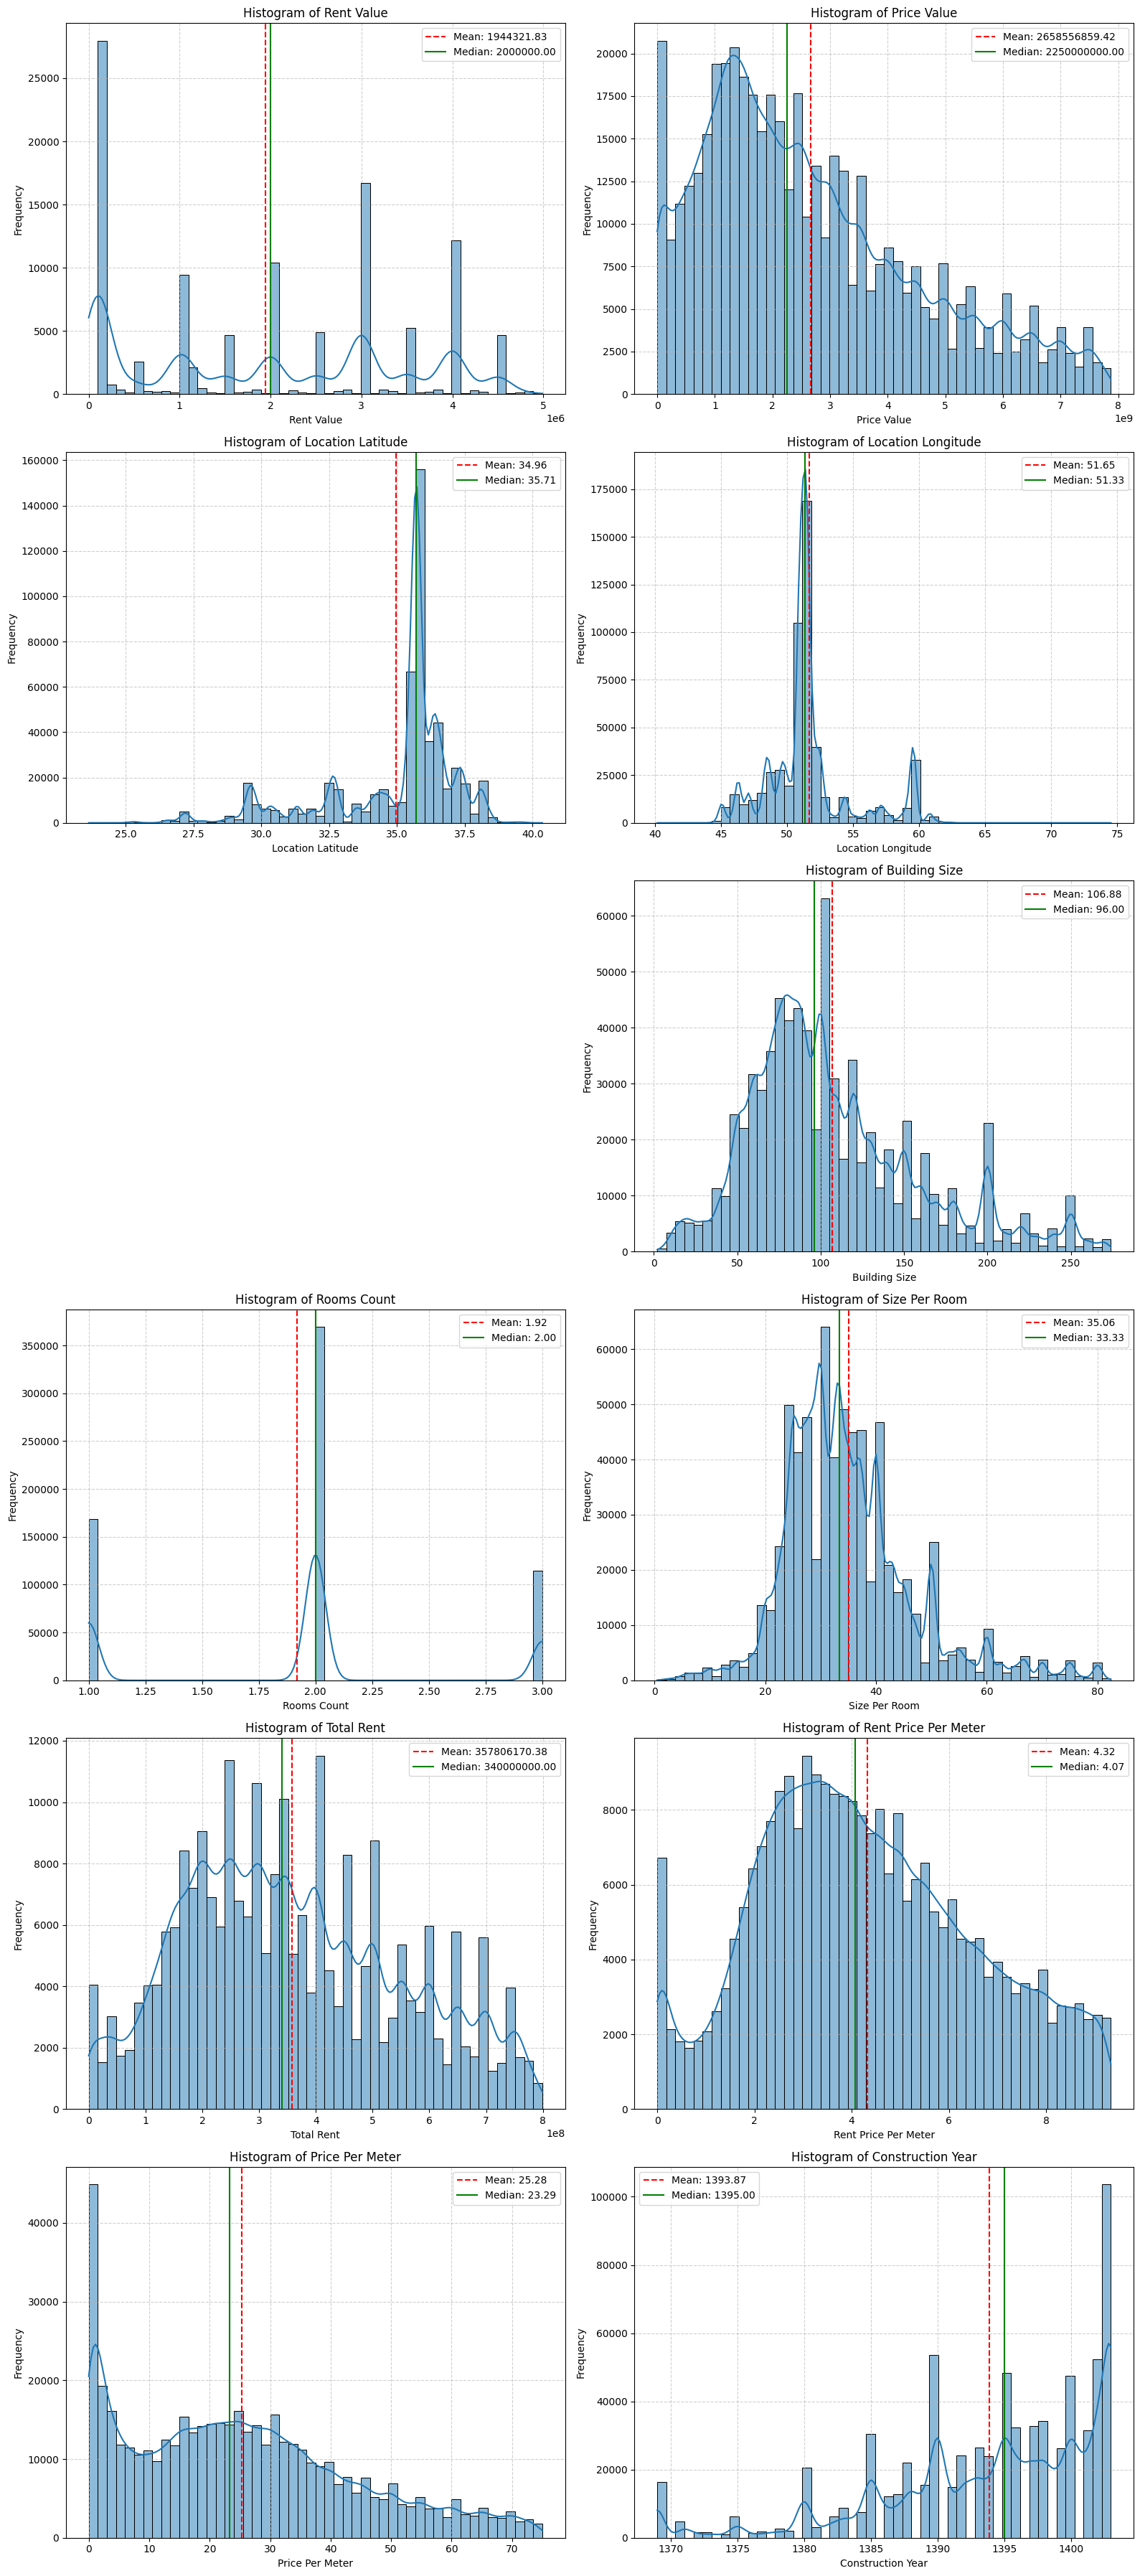

In [66]:
numerical_features_to_plot = ['rent_value','price_value','location_latitude','location_longitude','land_size','building_size','rooms_count',
                             'size_per_room','total_rent','rent_price_per_meter','price_per_meter','construction_year']
num_features = len(numerical_features_to_plot)
num_cols = 2
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6))
axes = axes.flatten()

for i, feature in enumerate(numerical_features_to_plot):
    ax = axes[i]
    
    temp_data = df[feature]
    temp_data = pd.to_numeric(temp_data, errors='coerce')

    
    Q1 = temp_data.quantile(0.25)
    Q3 = temp_data.quantile(0.75)
    IQR = Q3 - Q1

    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers and non-zero values
    temp_series = temp_data[(temp_data > lower_bound) & (temp_data < upper_bound)].dropna()
    temp_series = temp_series[temp_series != 0]

    if temp_series.empty:
        print(f"No data remaining for '{feature}' after outlier removal or after removing zero values. Skipping plot.")
        # Clear the subplot if no data to plot
        fig.delaxes(axes[i])
        continue

    mean_val = temp_series.mean()
    median_val = temp_series.median()

    sns.histplot(temp_series, kde=True, bins=50, ax=ax)

    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

    ax.set_title(f'Histogram of {feature.replace("_", " ").title()}')
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Remove any unused subplots if the number of features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


📌categorical features consider for showing histogram are ['cat2_slug', 'cat3_slug', 'user_type', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'floor', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material', 'mode_rent_or_price'] 



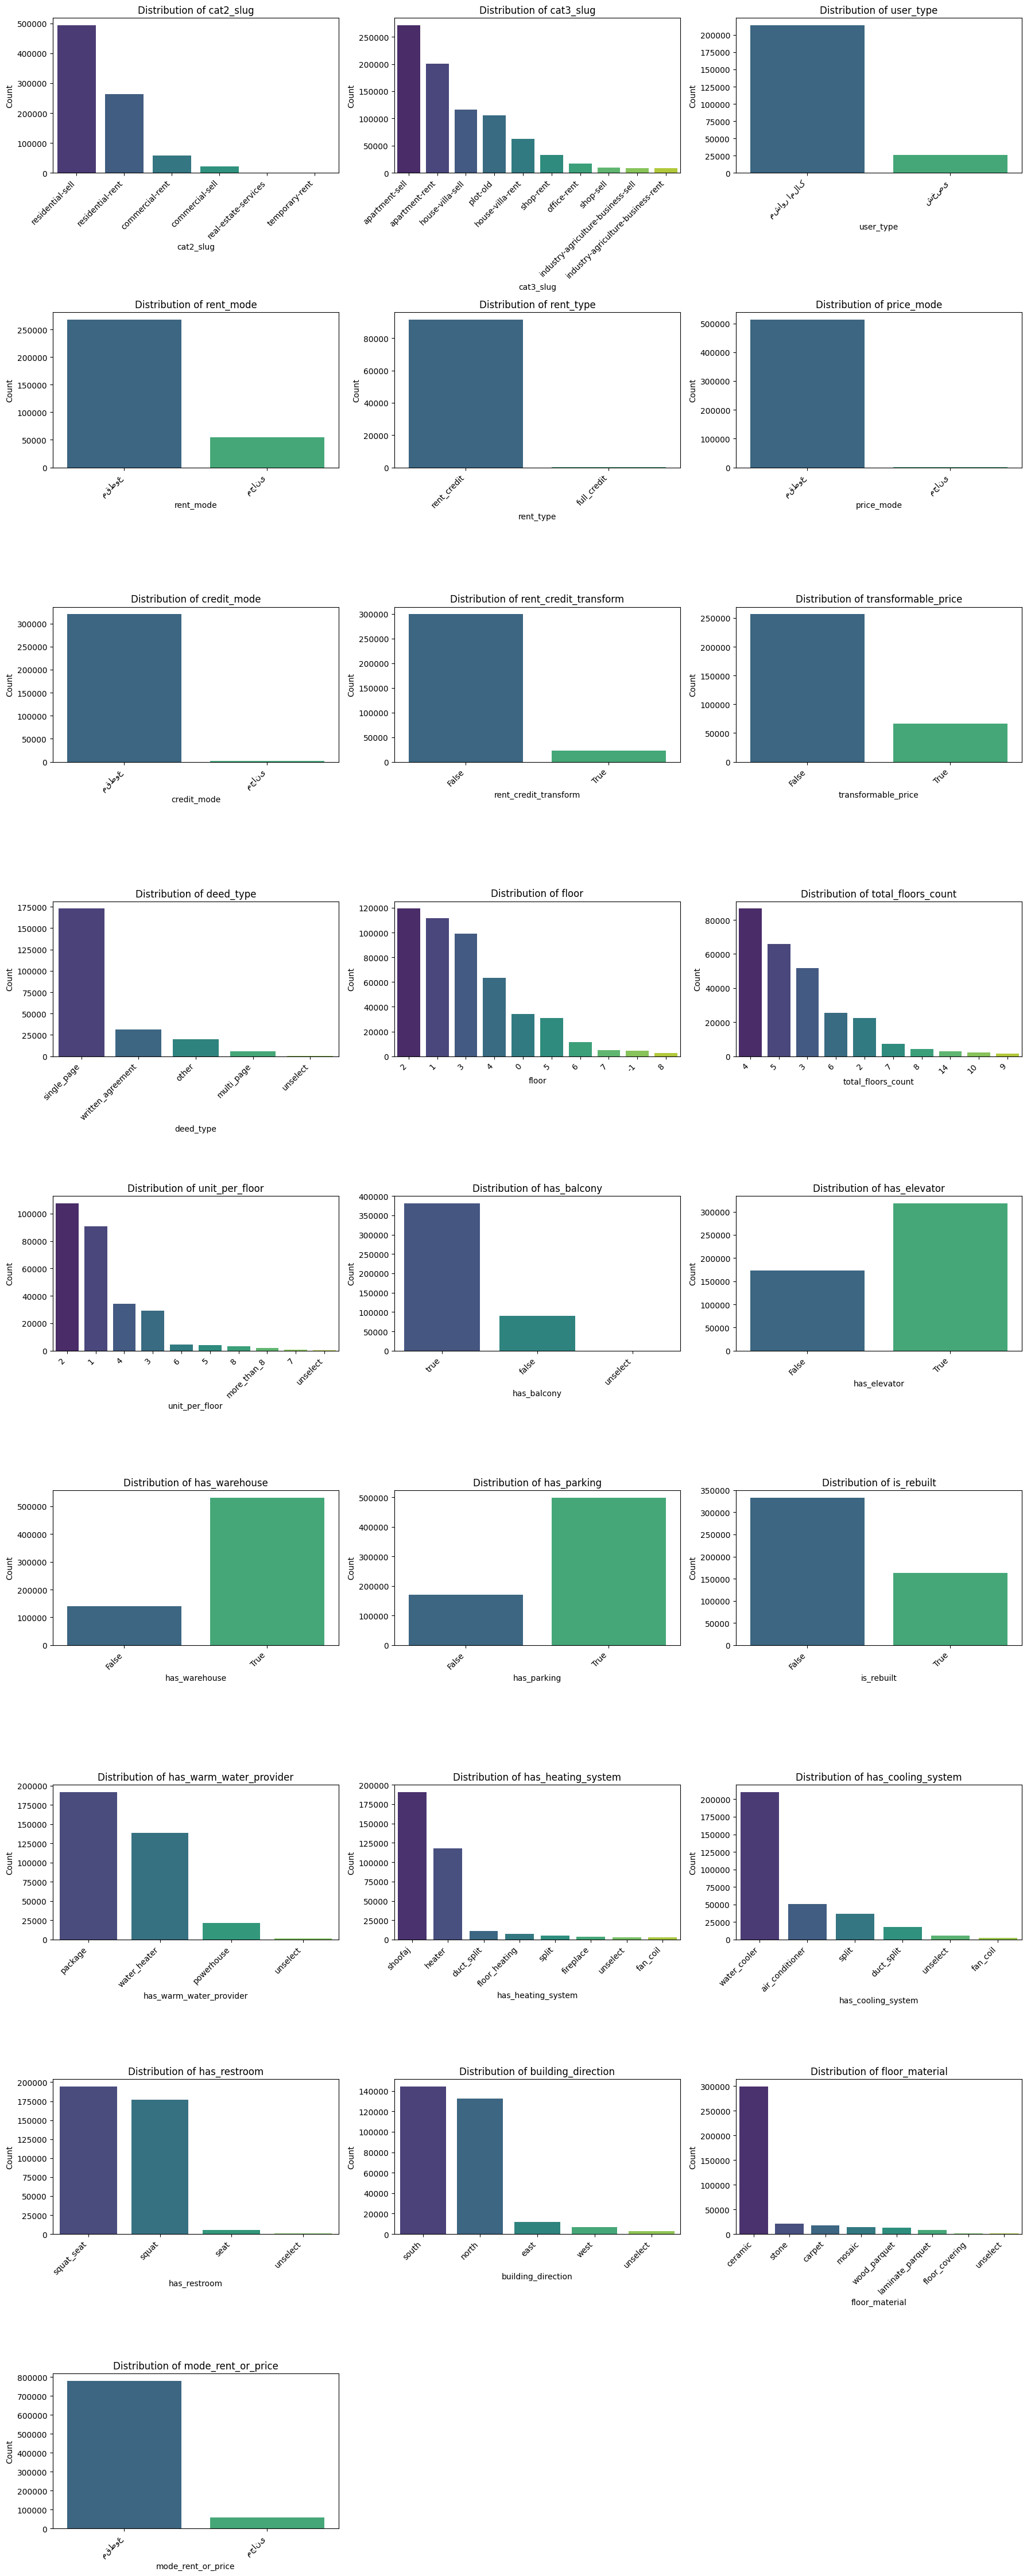

In [67]:
categorical_features = categorical

print('\n📌categorical features consider for showing histogram are',categorical,'\n' )
num_features = len(categorical_features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_features):
    ax = axes[i]

    value_counts = df[col].value_counts().head(10)
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12) # Reduced font size for subplots
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45) # Removed ha='right'
    ax.tick_params(axis='y', labelsize=10) # Adjust y-axis label size
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, ha='right') # Added ha='right' here

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار زیر توضیح دهنده نحوه توزیع قیمت یک مترمربع از فروش آپارتمان های مسکونی در نقاط مختلف کشور
</p>

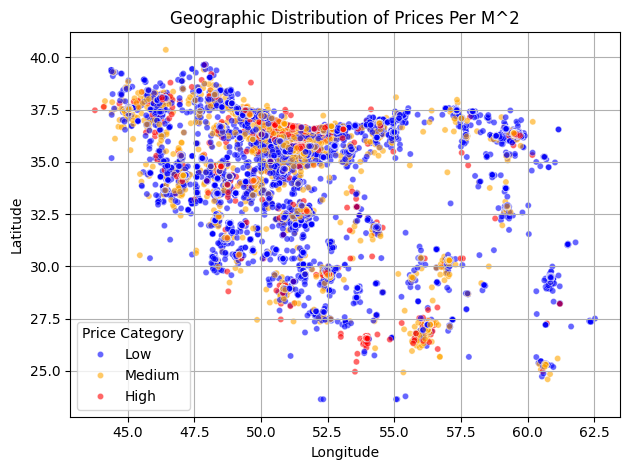

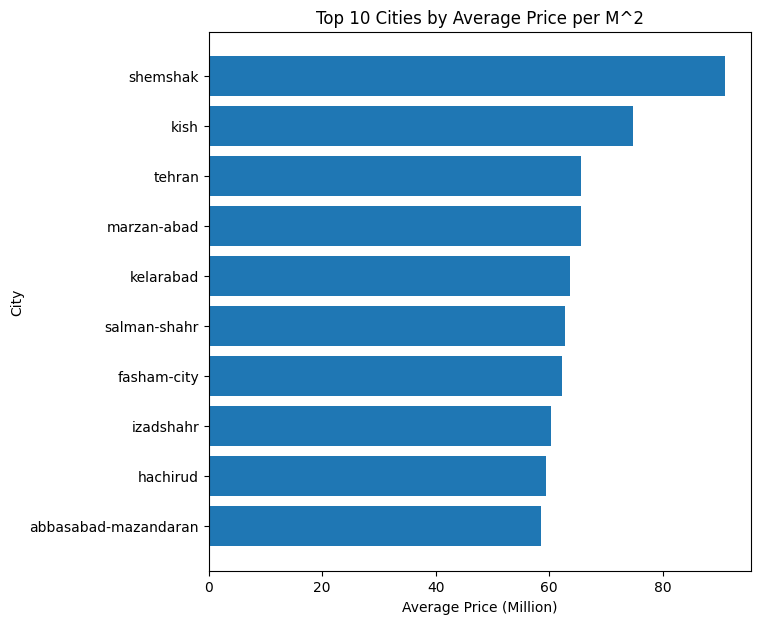

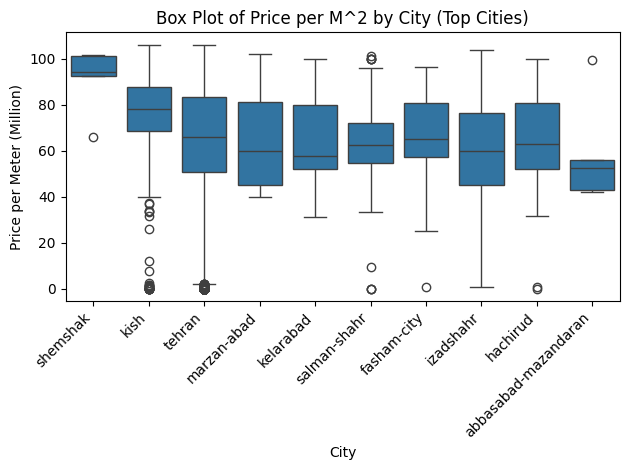

In [76]:

#exclude zero coordinated inserted during cleaning for handing nan.
df_temp = df_temp[(df_temp['location_latitude'] != 0.0) & (df_temp['location_longitude'] != 0.0)].copy()
df_temp = df_temp[(df['cat2_slug']=='residential-sell') & (df_temp['cat3_slug']=='apartment-sell')] 
# calculate bins and labels for price_category 
bins= [
    df_temp['price_per_meter'].min() - 1,
    df_temp['price_per_meter'].quantile(0.33),
    df_temp['price_per_meter'].quantile(0.66),
    df_temp['price_per_meter'].max() + 1
]
labels = ['Low', 'Medium', 'High']

df_temp['price_category'] = pd.cut(df_temp['price_per_meter'], bins=bins, labels=labels)

sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=df_temp,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.6,
    s=20
)
plt.title('Geographic Distribution of Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.grid(True)
plt.tight_layout()
plt.show()


avg_price_per_city = df_temp.groupby('city_slug')['price_per_meter'].mean().reset_index()
avg_price_per_city = avg_price_per_city.sort_values('price_per_meter', ascending=False)

avg_price_per_city = avg_price_per_city[avg_price_per_city['price_per_meter'].notnull()]

# Select top 10 cities for the bar chart
avg_price_per_city_top10 = avg_price_per_city.head(10)


plt.figure(figsize = (7, 7))
plt.barh(
    avg_price_per_city_top10['city_slug'],
    avg_price_per_city_top10['price_per_meter']
)
plt.xlabel('Average Price (Million)')
plt.ylabel('City')
plt.title('Top 10 Cities by Average Price per M^2')
plt.gca().invert_yaxis()
plt.show()

top_cities = avg_price_per_city.head(10)['city_slug'].tolist()
df_temp_top_cities = df_temp[df_temp['city_slug'].isin(top_cities)].copy()

#plt.figure(figsize=(7, 7))
sns.boxplot(x='city_slug', y='price_per_meter', data=df_temp_top_cities, order=top_cities) # Order by average price
plt.title('Box Plot of Price per M^2 by City (Top Cities)')
plt.xlabel('City')
plt.ylabel('Price per Meter (Million)')df[df['construction_year'].isin([1380, 1381, 1382, 1383, 1384, 1385])].to_csv(
    'cons_year_80.csv', 
    encoding='utf-8', 
    index=False
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

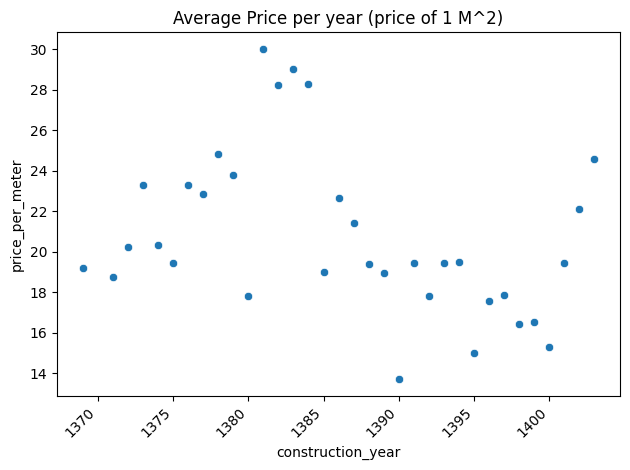

In [84]:
df_avg_year = df[df.construction_year != 0]
avg_price_per_year = df_avg_year.groupby('construction_year')['price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
#plot data
sns.scatterplot(x = 'construction_year', y = 'price_per_meter', data = avg_price_per_year)
plt.title('Average Price per year (price of 1 M^2)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

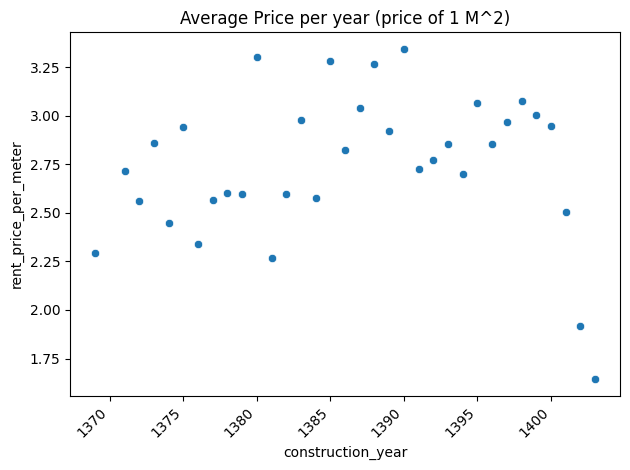

In [91]:
df_avg_year = df[df.construction_year != 0]
avg_price_per_year = df_avg_year.groupby('construction_year')['rent_price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
#plot data
sns.scatterplot(x = 'construction_year', y = 'rent_price_per_meter', data = avg_price_per_year)
plt.title('Average Price per year (price of 1 M^2)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. ارتباط دو به دوی تعدادی از متغیرها را که تصور می‌کنید به فهم داده کمک می‌کنند، بررسی کنید.
</p>

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['total_rent'].quantile(0.25)
Q3 = data2['total_rent'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data4 = data2[(data2['cat2_slug']=='residential-rent') &
              (data2['cat3_slug']=='apartment-rent') &
              (data2['total_rent'] > lower_bound) &
              (data2['total_rent'] < upper_bound)]

bins = [data4['rent_price_per_meter'].min()-1, data4['rent_price_per_meter'].quantile(0.33),
       data4['rent_price_per_meter'].quantile(0.66), data4['rent_price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data4['price_category'] = pd.cut(data4['rent_price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data4,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Rent Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()

avg_rent_per_city = data4.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_city = avg_rent_per_city.sort_values('rent_price_per_meter', ascending=False)
avg_rent_per_city[avg_rent_per_city['rent_price_per_meter'].notnull()]
avg_rent_per_city = avg_rent_per_city.head(10)
plt.figure(figsize = (5, 5))

plt.barh(
    avg_rent_per_city['city_slug'],
    avg_rent_per_city['rent_price_per_meter']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis()
plt.show()



<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. نکات قابل توجهی را که از بررسی توزیع‌ها و نمودارهای پراکندگی و مقدار همبستگی دریافتید فهرست کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.
</p>